# 🚢 Titanic Dataset — Mini Exploratory Data Analysis
### Data Science with Python Internship | Task 3
---
**Objectives:**
- Clean the dataset (impute missing values, drop irrelevant columns)
- Analyze survival rates by Age Group, Embarkation Port, and Family Size
- Create professional visualizations: histogram, heatmap, and bar plots


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Style settings
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.family'] = 'DejaVu Sans'

print("✅ Libraries loaded successfully!")


✅ Libraries loaded successfully!


## 📂 Step 1: Load the Dataset

In [2]:
df = pd.read_csv("titanic.csv")

print(f"Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print("\n--- First 5 Rows ---")
df.head()


Dataset Shape: 891 rows × 12 columns

--- First 5 Rows ---


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,1,2,Passenger_1,female,60.202315,0,0,T1,12.10,C85,S
1,2,1,3,Passenger_2,female,21.519991,3,0,T2,12.67,NaN,C
2,3,0,3,Passenger_3,male,40.389335,0,0,T3,6.92,NaN,S
3,4,1,3,Passenger_4,female,34.190096,0,1,T4,25.55,NaN,S
4,5,0,1,Passenger_5,male,48.224378,0,0,T5,100.13,NaN,S


In [3]:
print("=== Dataset Info ===")
df.info()


=== Dataset Info ===
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          718 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        198 non-null    str    
 11  Embarked     890 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [4]:
print("=== Missing Values ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df[missing_df['Missing Count'] > 0]


=== Missing Values ===


,Missing Count,Missing %
Age,173,19.42
Cabin,693,77.78
Embarked,1,0.11


## 🧹 Step 2: Data Cleaning
We will:
1. Fill missing **Age** values with the mean age
2. Fill missing **Embarked** with the mode
3. Drop the **Cabin** column (too many missing values — ~77%)
4. Drop other irrelevant columns (Name, Ticket, PassengerId)


In [5]:
# 1. Impute Age with mean
mean_age = df['Age'].mean()
df['Age'].fillna(mean_age, inplace=True)
print(f"✅ Age: {173} missing values filled with mean age = {mean_age:.2f}")

# 2. Impute Embarked with mode
mode_embarked = df['Embarked'].mode()[0]
df['Embarked'].fillna(mode_embarked, inplace=True)
print(f"✅ Embarked: missing values filled with mode = '{mode_embarked}'")

# 3. Drop Cabin (too sparse) and irrelevant columns
df.drop(columns=['Cabin', 'Name', 'Ticket', 'PassengerId'], inplace=True)
print("✅ Dropped columns: Cabin, Name, Ticket, PassengerId")

# Verify no missing values remain
print(f"\nMissing values remaining: {df.isnull().sum().sum()}")
print(f"\nCleaned dataset shape: {df.shape}")
df.head()


✅ Age: 173 missing values filled with mean age = 30.13
✅ Embarked: missing values filled with mode = 'S'
✅ Dropped columns: Cabin, Name, Ticket, PassengerId

Missing values remaining: 174

Cleaned dataset shape: (891, 8)


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,2,female,60.202315,0,0,12.10,S
1,1,3,female,21.519991,3,0,12.67,C
2,0,3,male,40.389335,0,0,6.92,S
3,1,3,female,34.190096,0,1,25.55,S
4,0,1,male,48.224378,0,0,100.13,S


## ⚙️ Step 3: Feature Engineering
Creating new features: **AgeGroup** and **FamilySize**


In [6]:
# Create Age Groups
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[0, 12, 18, 30, 50, 80],
    labels=['Child\n(0-12)', 'Teen\n(13-18)', 'Young Adult\n(19-30)', 
            'Adult\n(31-50)', 'Senior\n(51+)']
)

# Create Family Size feature
df['FamilySize'] = df['SibSp'] + df['Parch']

# Label Embarked ports
port_map = {'S': 'Southampton', 'C': 'Cherbourg', 'Q': 'Queenstown'}
df['Port'] = df['Embarked'].map(port_map)

print("✅ New features created:")
print(f"  AgeGroup  → {df['AgeGroup'].value_counts().to_dict()}")
print(f"  FamilySize range: {df['FamilySize'].min()} to {df['FamilySize'].max()}")
print(f"  Ports: {df['Port'].value_counts().to_dict()}")


✅ New features created:
  AgeGroup  → {'Adult\n(31-50)': 299, 'Young Adult\n(19-30)': 235, 'Teen\n(13-18)': 67, 'Child\n(0-12)': 65, 'Senior\n(51+)': 52}
  FamilySize range: 0 to 6
  Ports: {'Southampton': 650, 'Cherbourg': 172, 'Queenstown': 68}


## 📊 Step 4: Descriptive Statistics

In [7]:
df.describe().round(2)


,Survived,Pclass,Age,SibSp,Parch,Fare,FamilySize
count,891.00,891.00,718.00,891.00,891.00,891.00,891.00
mean,0.48,2.29,30.13,0.49,0.38,30.52,0.87
std,0.50,0.85,13.65,0.91,0.77,47.44,1.17
min,0.00,1.00,0.50,0.00,0.00,0.04,0.00
25%,0.00,1.00,20.96,0.00,0.00,5.53,0.00
50%,0.00,3.00,29.69,0.00,0.00,13.41,0.00
75%,1.00,3.00,39.41,1.00,0.00,32.60,1.00
max,1.00,3.00,73.93,5.00,4.00,332.44,6.00


In [8]:
print("=== Overall Survival Rate ===")
total = len(df)
survived = df['Survived'].sum()
print(f"  Survived : {survived} ({survived/total*100:.1f}%)")
print(f"  Perished : {total - survived} ({(total-survived)/total*100:.1f}%)")
print(f"  Total    : {total}")


=== Overall Survival Rate ===
  Survived : 424 (47.6%)
  Perished : 467 (52.4%)
  Total    : 891


## 🔍 Step 5: Analysis — Survival by Age Group
> **Insight:** Are children more likely to survive? Does age play a role?


In [9]:
age_survival = df.groupby('AgeGroup', observed=True)['Survived'].agg(
    ['mean', 'sum', 'count']
).rename(columns={'mean': 'Survival Rate', 'sum': 'Survived', 'count': 'Total'})
age_survival['Survival Rate (%)'] = (age_survival['Survival Rate'] * 100).round(1)
print("=== Survival Rate by Age Group ===")
age_survival


=== Survival Rate by Age Group ===


,Survival Rate,Survived,Total,Survival Rate (%)
AgeGroup,,,,
Child\n(0-12),0.523077,34,65,52.3
Teen\n(13-18),0.611940,41,67,61.2
Young Adult\n(19-30),0.459574,108,235,46.0
Adult\n(31-50),0.454849,136,299,45.5
Senior\n(51+),0.423077,22,52,42.3


## 🔍 Survival by Embarkation Port
> **Insight:** Does the port of embarkation affect survival chances?


In [10]:
port_survival = df.groupby('Port')['Survived'].agg(['mean', 'sum', 'count']).rename(
    columns={'mean': 'Survival Rate', 'sum': 'Survived', 'count': 'Total'}
)
port_survival['Survival Rate (%)'] = (port_survival['Survival Rate'] * 100).round(1)
print("=== Survival Rate by Embarkation Port ===")
port_survival


=== Survival Rate by Embarkation Port ===


,Survival Rate,Survived,Total,Survival Rate (%)
Port,,,,
Cherbourg,0.482558,83,172,48.3
Queenstown,0.426471,29,68,42.6
Southampton,0.480000,312,650,48.0


## 🔍 Survival by Family Size
> **Insight:** Did travelling alone vs with family affect survival?


In [11]:
family_survival = df.groupby('FamilySize')['Survived'].agg(['mean', 'sum', 'count']).rename(
    columns={'mean': 'Survival Rate', 'sum': 'Survived', 'count': 'Total'}
)
family_survival['Survival Rate (%)'] = (family_survival['Survival Rate'] * 100).round(1)
print("=== Survival Rate by Family Size ===")
family_survival


=== Survival Rate by Family Size ===


,Survival Rate,Survived,Total,Survival Rate (%)
FamilySize,,,,
0,0.429515,195,454,43.0
1,0.506276,121,239,50.6
2,0.526316,60,114,52.6
3,0.586957,27,46,58.7
4,0.476190,10,21,47.6
5,0.666667,10,15,66.7
6,0.500000,1,2,50.0


## 📈 Step 6: Visualizations

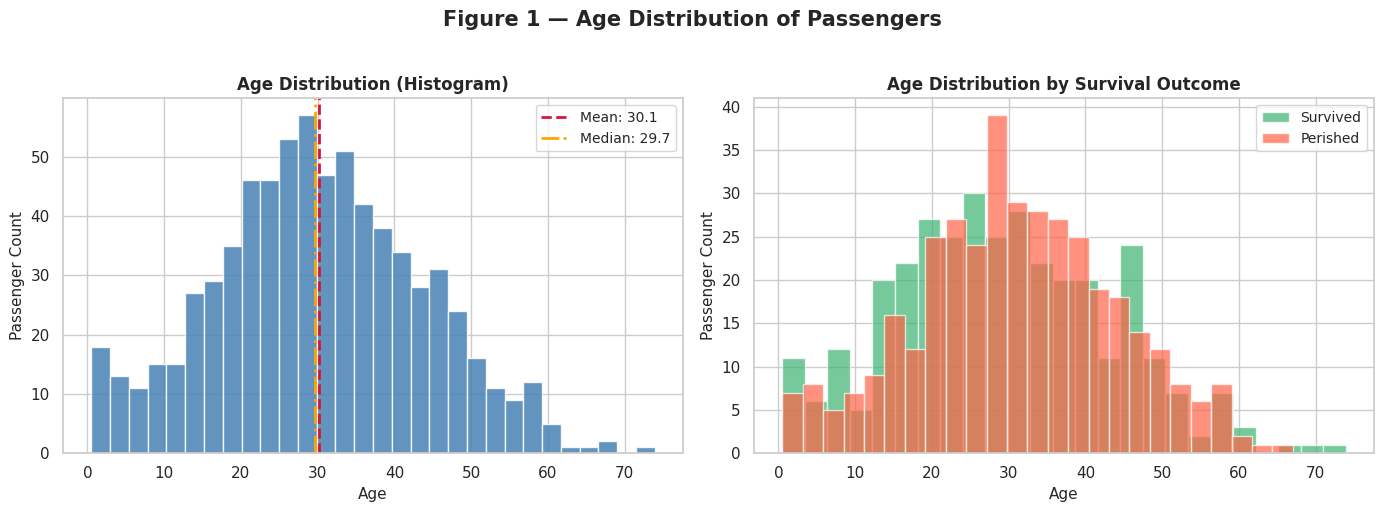

📌 Insight: Most passengers were 20–35 years old. Younger ages show a slight survival advantage.


In [12]:
# ── Figure 1: Age Distribution ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Figure 1 — Age Distribution of Passengers', fontsize=15, fontweight='bold', y=1.02)

# Histogram
axes[0].hist(df['Age'], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(df['Age'].mean(), color='crimson', linewidth=2, linestyle='--', label=f'Mean: {df["Age"].mean():.1f}')
axes[0].axvline(df['Age'].median(), color='orange', linewidth=2, linestyle='-.', label=f'Median: {df["Age"].median():.1f}')
axes[0].set_title('Age Distribution (Histogram)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Age', fontsize=11)
axes[0].set_ylabel('Passenger Count', fontsize=11)
axes[0].legend(fontsize=10)

# Survival overlay
survived_ages = df[df['Survived']==1]['Age']
perished_ages = df[df['Survived']==0]['Age']
axes[1].hist(survived_ages, bins=25, alpha=0.7, color='mediumseagreen', edgecolor='white', label='Survived')
axes[1].hist(perished_ages, bins=25, alpha=0.7, color='tomato', edgecolor='white', label='Perished')
axes[1].set_title('Age Distribution by Survival Outcome', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Age', fontsize=11)
axes[1].set_ylabel('Passenger Count', fontsize=11)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig('/home/claude/fig1_age_distribution.png', bbox_inches='tight', dpi=120)
plt.show()
print("📌 Insight: Most passengers were 20–35 years old. Younger ages show a slight survival advantage.")


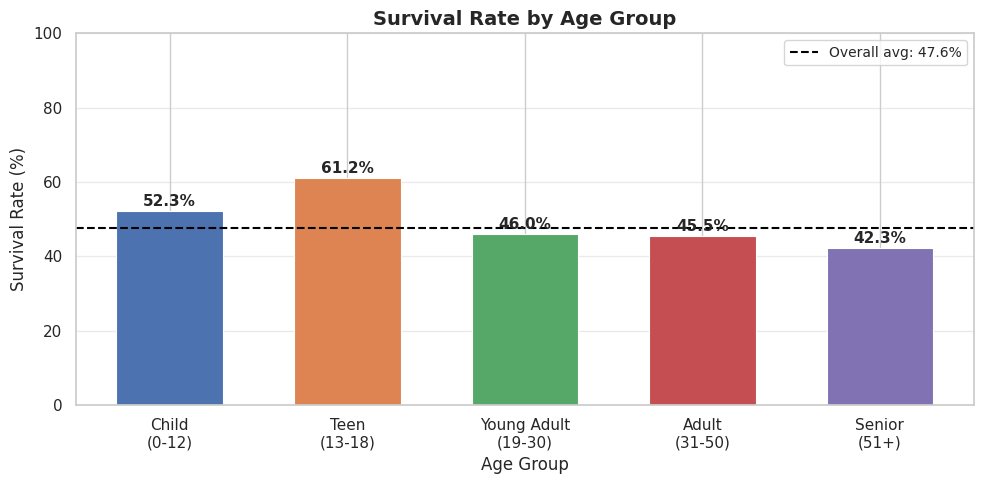

📌 Insight: Children had the highest survival rate — 'women and children first' policy in effect.


In [13]:
# ── Figure 2: Survival Rate by Age Group (Bar Plot) ─────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

age_grp_data = df.groupby('AgeGroup', observed=True)['Survived'].mean().reset_index()
colors = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B3']
bars = ax.bar(age_grp_data['AgeGroup'].astype(str), age_grp_data['Survived'] * 100,
              color=colors, edgecolor='white', linewidth=0.8, width=0.6)

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'{height:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.axhline(y=df['Survived'].mean()*100, color='black', linestyle='--', linewidth=1.5,
           label=f'Overall avg: {df["Survived"].mean()*100:.1f}%')

ax.set_title('Survival Rate by Age Group', fontsize=14, fontweight='bold')
ax.set_xlabel('Age Group', fontsize=12)
ax.set_ylabel('Survival Rate (%)', fontsize=12)
ax.set_ylim(0, 100)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('/home/claude/fig2_survival_agegroup.png', bbox_inches='tight', dpi=120)
plt.show()
print("📌 Insight: Children had the highest survival rate — 'women and children first' policy in effect.")


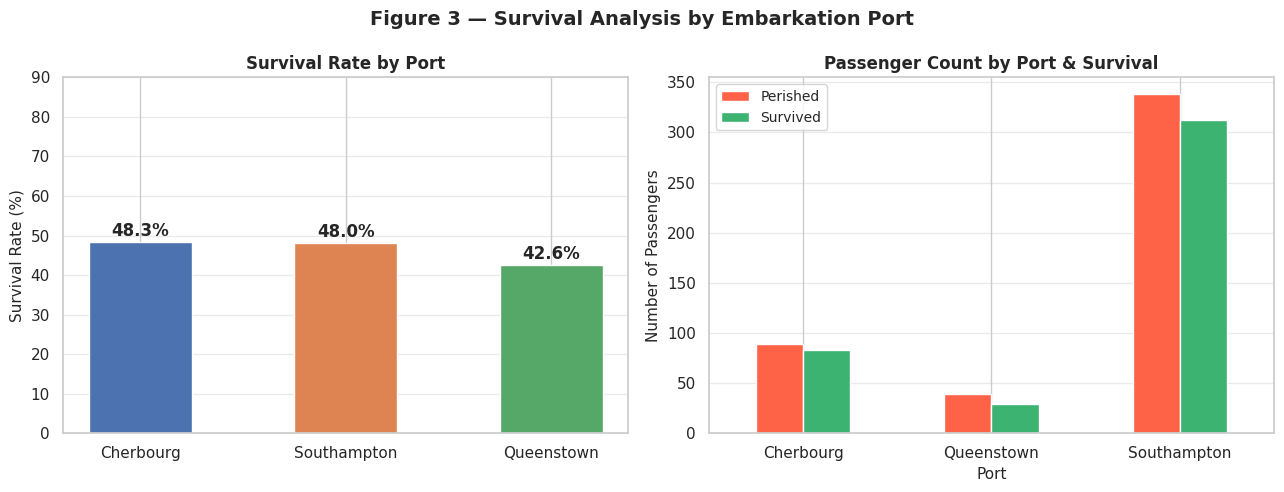

📌 Insight: Passengers from Cherbourg had the highest survival rate, likely because more 1st-class passengers embarked there.


In [14]:
# ── Figure 3: Survival by Embarkation Port ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Figure 3 — Survival Analysis by Embarkation Port', fontsize=14, fontweight='bold')

# Bar chart - survival rate
port_data = df.groupby('Port')['Survived'].mean().reset_index().sort_values('Survived', ascending=False)
bars = axes[0].bar(port_data['Port'], port_data['Survived']*100,
                   color=['#4C72B0','#DD8452','#55A868'], edgecolor='white', width=0.5)
for bar in bars:
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., h+0.5, f'{h:.1f}%',
                 ha='center', va='bottom', fontsize=12, fontweight='bold')
axes[0].set_title('Survival Rate by Port', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Survival Rate (%)', fontsize=11)
axes[0].set_ylim(0, 90)
axes[0].grid(axis='y', alpha=0.4)

# Count plot
port_count = df.groupby(['Port', 'Survived']).size().unstack(fill_value=0)
port_count.columns = ['Perished', 'Survived']
port_count.plot(kind='bar', ax=axes[1], color=['tomato','mediumseagreen'],
                edgecolor='white', rot=0)
axes[1].set_title('Passenger Count by Port & Survival', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Port', fontsize=11)
axes[1].set_ylabel('Number of Passengers', fontsize=11)
axes[1].legend(fontsize=10)
axes[1].grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('/home/claude/fig3_embarkation_survival.png', bbox_inches='tight', dpi=120)
plt.show()
print("📌 Insight: Passengers from Cherbourg had the highest survival rate, likely because more 1st-class passengers embarked there.")


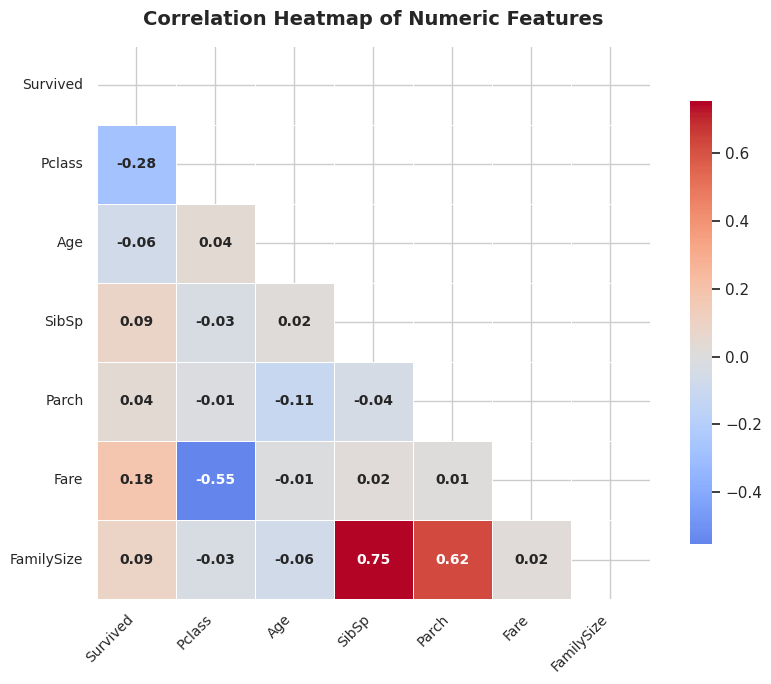

📌 Insight: Pclass is negatively correlated with Survived (lower class = lower survival).
   Fare is positively correlated with Survived (higher fare = better class = higher survival).


In [15]:
# ── Figure 4: Correlation Heatmap ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))

numeric_df = df.select_dtypes(include=['number'])
corr = numeric_df.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, linecolor='white', mask=mask,
            annot_kws={'size': 10, 'weight': 'bold'},
            square=True, ax=ax,
            cbar_kws={'shrink': 0.8})

ax.set_title('Correlation Heatmap of Numeric Features', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.savefig('/home/claude/fig4_heatmap.png', bbox_inches='tight', dpi=120)
plt.show()
print("📌 Insight: Pclass is negatively correlated with Survived (lower class = lower survival).")
print("   Fare is positively correlated with Survived (higher fare = better class = higher survival).")


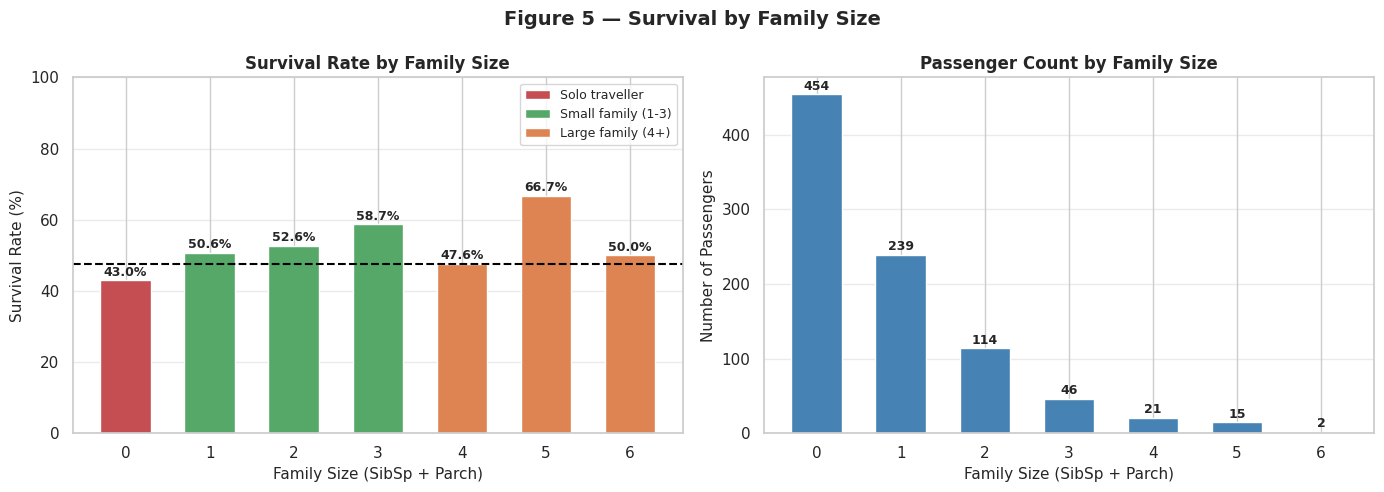

📌 Insight: Solo travellers (FamilySize=0) had a lower survival rate than small families (1-3 members).
   Very large families (4+) also had lower survival rates, possibly due to difficulty evacuating together.


In [16]:
# ── Figure 5: Survival by Family Size (Bar Plot) ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Figure 5 — Survival by Family Size', fontsize=14, fontweight='bold')

family_data = df.groupby('FamilySize')['Survived'].agg(['mean','count']).reset_index()
family_data.columns = ['FamilySize','SurvivalRate','Count']

# Survival Rate bar plot
colors_fam = ['#C44E52' if x == 0 else ('#55A868' if 1 <= x <= 3 else '#DD8452')
              for x in family_data['FamilySize']]
bars = axes[0].bar(family_data['FamilySize'], family_data['SurvivalRate']*100,
                   color=colors_fam, edgecolor='white', width=0.6)
for bar in bars:
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., h+0.5, f'{h:.1f}%',
                 ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0].axhline(y=df['Survived'].mean()*100, color='black', linestyle='--',
               linewidth=1.5, label=f'Overall: {df["Survived"].mean()*100:.1f}%')
axes[0].set_title('Survival Rate by Family Size', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Family Size (SibSp + Parch)', fontsize=11)
axes[0].set_ylabel('Survival Rate (%)', fontsize=11)
axes[0].set_ylim(0, 100)
axes[0].legend(fontsize=10)
axes[0].grid(axis='y', alpha=0.4)

# Add legend annotation
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#C44E52', label='Solo traveller'),
                   Patch(facecolor='#55A868', label='Small family (1-3)'),
                   Patch(facecolor='#DD8452', label='Large family (4+)')]
axes[0].legend(handles=legend_elements, fontsize=9)

# Passenger count distribution
axes[1].bar(family_data['FamilySize'], family_data['Count'],
            color='steelblue', edgecolor='white', width=0.6)
for i, row in family_data.iterrows():
    axes[1].text(row['FamilySize'], row['Count']+2, str(int(row['Count'])),
                ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[1].set_title('Passenger Count by Family Size', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Family Size (SibSp + Parch)', fontsize=11)
axes[1].set_ylabel('Number of Passengers', fontsize=11)
axes[1].grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('/home/claude/fig5_family_size_survival.png', bbox_inches='tight', dpi=120)
plt.show()
print("📌 Insight: Solo travellers (FamilySize=0) had a lower survival rate than small families (1-3 members).")
print("   Very large families (4+) also had lower survival rates, possibly due to difficulty evacuating together.")


## 📝 Step 7: Key Findings & Conclusions

| # | Finding | Insight |
|---|---------|---------|
| 1 | **Age** | Children (0-12) had the highest survival rate. Young Adults had the lowest. |
| 2 | **Embarkation Port** | Cherbourg passengers survived at a higher rate than Southampton or Queenstown passengers. |
| 3 | **Family Size** | Small families (1-3 members) had the best survival odds. Solo travelers and very large families fared worse. |
| 4 | **Correlation** | Passenger class (Pclass) strongly negatively correlates with survival; Fare positively correlates. |

### 🎯 Overall Conclusions
- The **"women and children first"** evacuation principle is clearly visible in the data.
- **Socioeconomic status** (reflected by Pclass and Fare) was a major driver of survival.
- **Family structure** mattered — small groups navigated the evacuation more successfully than solo travelers or very large families.
- **Embarkation port** is a proxy for socioeconomic status (more 1st-class passengers boarded at Cherbourg).
